# O Método de Monte Carlo – Modelo de Ising 2D usando Algoritmo de Metropolis

Vinicius Trindade Dias Abel

## Parte 1 - Processo de Termalização

O Processo de Termalização é a fase inicial de uma simulação de Monte Carlo onde o sistema evolui para atingir o equilíbrio termodinâmico. Durante esse processo, as configurações iniciais são descartadas até que o sistema comece a oscilar ao redor de um valor médio estável, indicando que atingiu o estado estacionário.

### Modelo de Ising

O modelo de Ising é usado na termalização para estudar como sistemas físicos atingem o equilíbrio termodinâmico. Ele simula uma rede de spins, facilitando a análise da energia e magnetização enquanto o sistema se ajusta ao equilíbrio.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

In [ ]:
def vizinhos(S):
  N = len(S)
  L= np.sqrt(N)
  viz = np.zeros((N,4), dtype=np.int16)

  for k in range(N):
    viz[k, 0] =  k + 1
    if (k + 1) % L == 0 : viz[k, 0] = k + 1 - L

    viz[k, 1] = k + L
    if k > (N - L - 1) : viz[k, 1] = k + L - N

    viz[k, 2] = k - 1
    if k % L == 0 : viz[k, 2] = k + L - 1

    viz[k, 3] = k - L
    if k < L : viz[k, 3] = k + N - L

  return viz

@jit(nopython = True)
def energia(S, viz):
  #Calcula a energia da configuração representada no array s
  N = len(S)
  ener = 0
  for i in range(N):
    h = (S[viz[i, 0]] + S[viz[i, 1]]) # soma do valor dos spins a direita e acima
    ener -= S[i] * h
  return ener

### Algoritmo de Metropolis

O algoritmo de Metropolis é utilizado no modelo de Ising para simular a evolução do sistema até o equilíbrio. Ele gera novas configurações de estados de acordo com a energia: configurações que diminuem a energia são aceitas automaticamente, enquanto aquelas que aumentam a energia são aceitas com uma certa probabilidade. Esse método permite que o sistema alcance gradualmente um estado de equilíbrio.

In [ ]:
@jit(nopython=True)
def expos(beta):
  ex = { -8: np.exp(8.0 * beta), -4: np.exp(4.0 * beta), 0: 1.0, 4: np.exp(-4.0 * beta), 8: np.exp(-8.0 * beta) }
  return ex

# Algoritmo de Metropolis
@jit(nopython = True)
def metropolis(S, viz, ener, mag, ex):
    N = len(S)
    for i in range(N):
        k = np.random.randint(N)

        h = S[viz[k, 0]] + S[viz[k, 1]] + S[viz[k, 2]] + S[viz[k, 3]]
        de = S[k] * h * 2

        if np.random.rand() < ex[de]:
            S[k] = -S[k]
            ener += de
            mag += 2 * S[k]

    return S, ener, mag

### Funções para criar e plotar as simulações

In [ ]:
def termalizacao(L, beta, passos_mc):
    N = L * L
    S = np.random.choice([-1, 1], size=N).astype(np.int8)
    viz = vizinhos(S)
    ener = energia(S, viz)
    mag = np.sum(S)
    ex = expos(beta)

    energias = []
    magnetizacoes = []

    for passo in range(passos_mc):
        S, ener, mag = metropolis(S, viz, ener, mag, ex)
        energias.append(ener)
        magnetizacoes.append(mag)

    return energias, magnetizacoes

In [ ]:
def simulacoes(L, beta, n, passos_mc):
    energias = []
    magnetizacoes = []

    for i in range(n):
        ener, mag = termalizacao(L, beta, passos_mc)
        energias.append(ener)
        magnetizacoes.append(mag)

    return (np.array(energias), np.array(magnetizacoes))

In [ ]:
def plotagem(titulo_1, titulo_2, energias, magnetizacoes, n):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    for i in range(n):
        ax1.plot(energias[i], linewidth=0.8, alpha=0.92)
    ax1.set_xlabel('Passos de Monte Carlo')
    ax1.set_ylabel('Energia')
    ax1.set_title(titulo_1)
    for i in range(n):
        ax2.plot(magnetizacoes[i], linewidth=0.8, alpha=0.92)
    ax2.set_xlabel('Passos de Monte Carlo')
    ax2.set_ylabel('Magnetização')
    ax2.set_title(titulo_2)

    plt.tight_layout()
    plt.show()

### Simulações

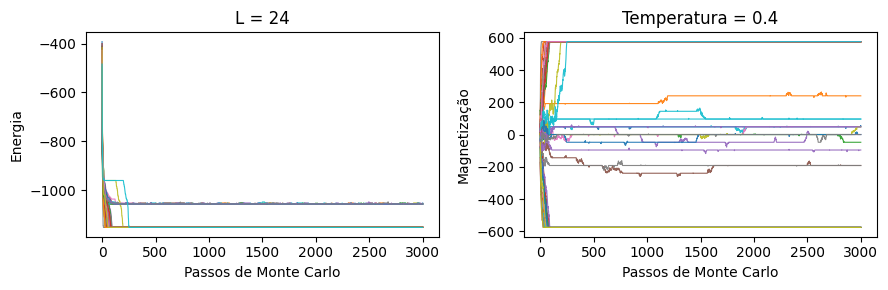

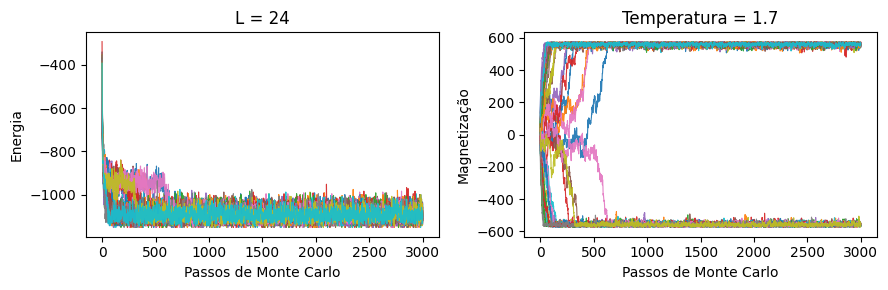

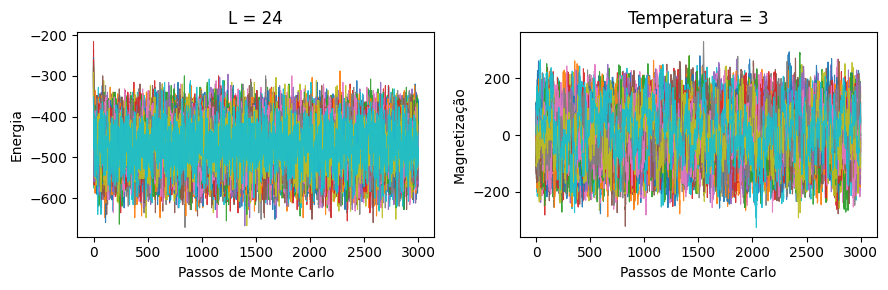

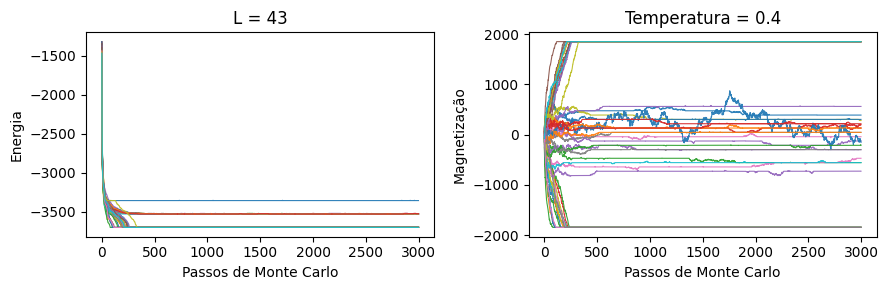

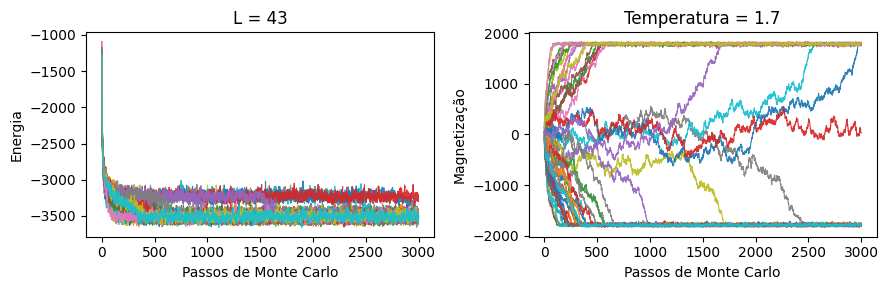

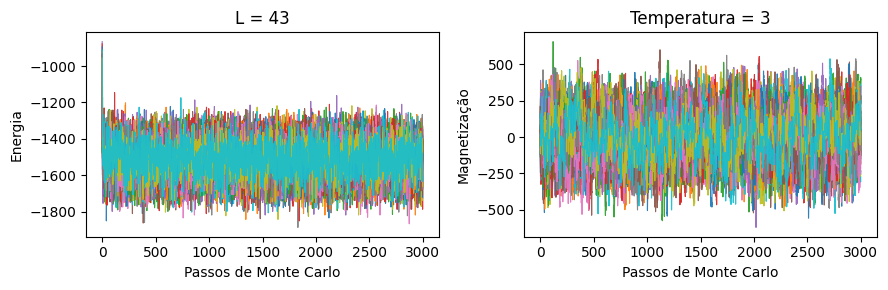

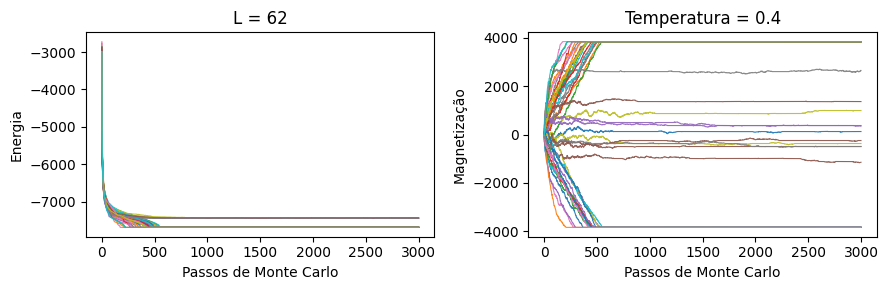

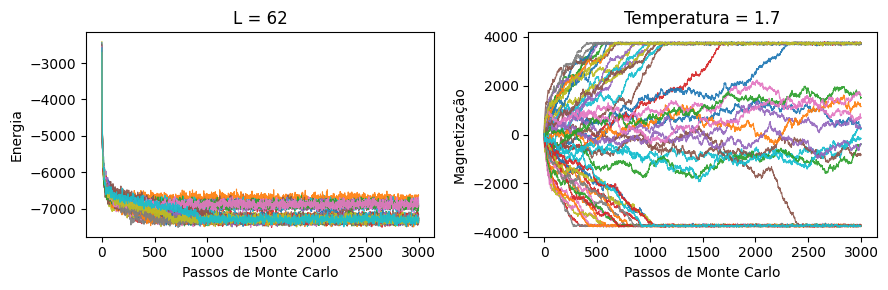

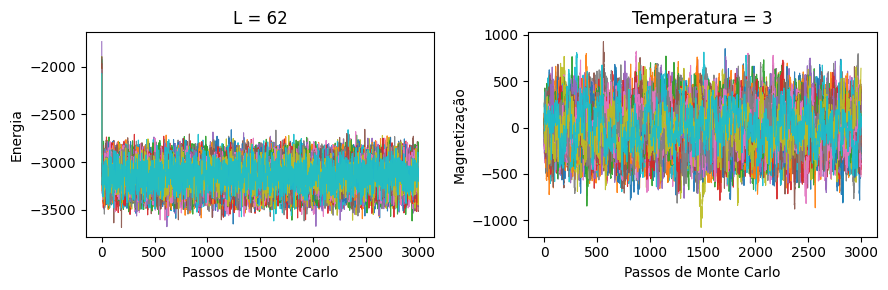

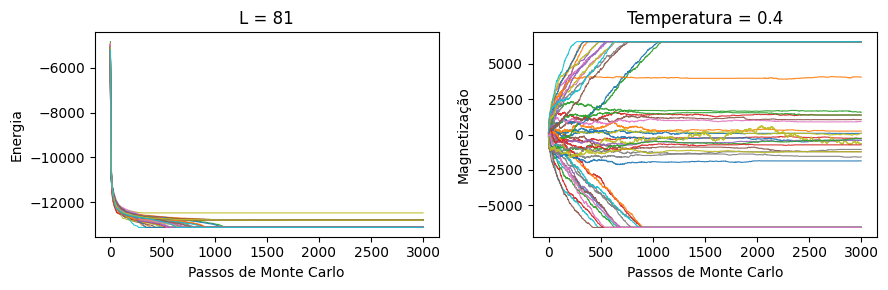

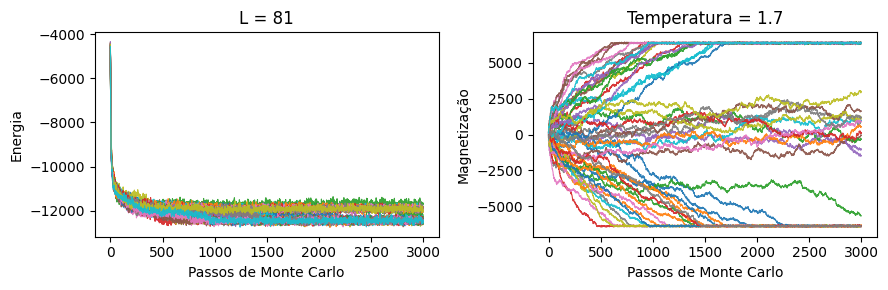

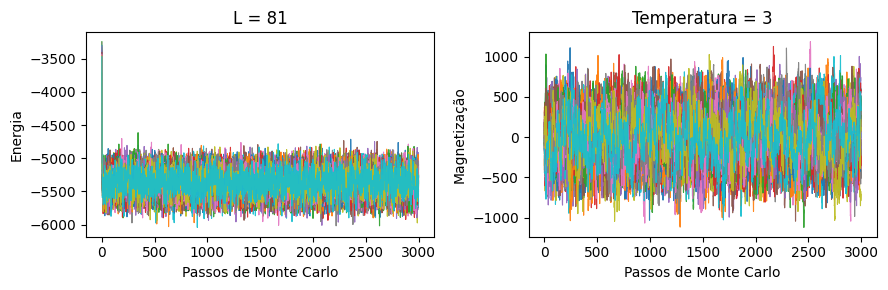

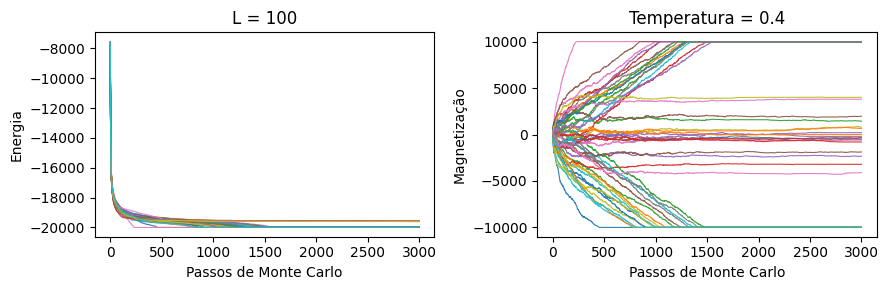

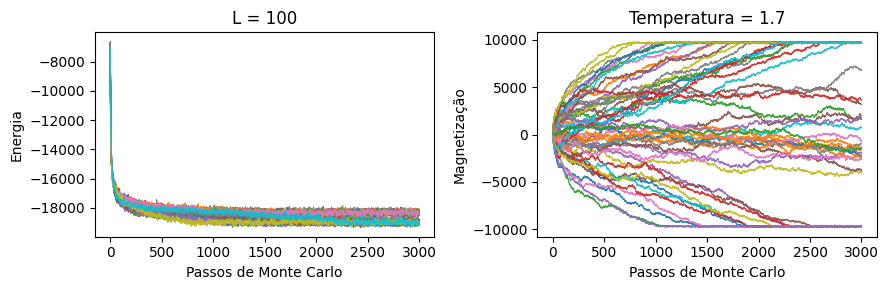

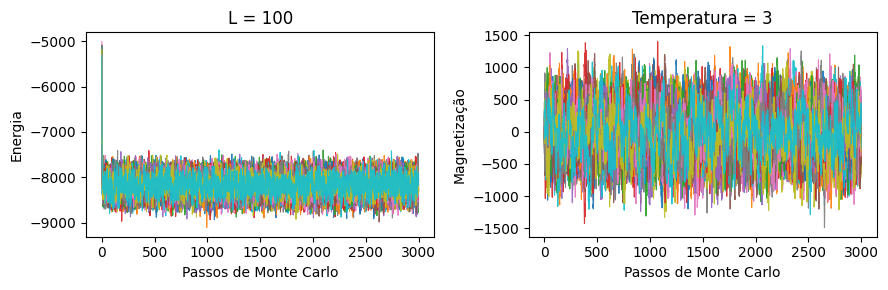

In [ ]:
# Parâmetros globais
passos_mc = 3000
n = 50

# Simulacoes L = 24
L = 24
T = 0.4
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 24", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 24", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 24", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 43
L = 43
T = 0.4
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 43", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 43", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 43", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 62
L = 62
T = 0.4
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 62", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 62", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 62", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 81
L = 81
T = 0.4
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 81", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 81", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 81", "Temperatura = 3", energias, magnetizacoes, n)

# Simulacoes L = 100
L = 100
T = 0.4
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 100", "Temperatura = 0.4", energias, magnetizacoes, n)

T = 1.7
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 100", "Temperatura = 1.7", energias, magnetizacoes, n)

T = 3
beta = 1 / T

energias, magnetizacoes = simulacoes(L, beta, n, passos_mc)
plotagem("L = 100", "Temperatura = 3", energias, magnetizacoes, n)

### Análise de Resultados

**Energia**

* Variação de Temperatura

  Com o aumento da temperatura, a energia do sistema leva mais tempo para convergir e tende a atingir valores mais altos, indicando maior desordem.

* Variação de L

  À medida que o tamanho da rede (L) aumenta, a energia de convergência diminui, o que leva a um valor total maior de interações. No entanto, o aumento de L não parece alterar o número de passos de Monte Carlo necessários para a estabilização.


**Magnetização**

* Variação de Temperatura

  Em baixas temperaturas, poucas instâncias convergem. Temperaturas medianas geram mais convergência, mas, em temperaturas elevadas, a magnetização se torna caótica, dificultando a estabilização.

* Variação de L

  Com o aumento de L, o valor de magnetização de convergência cresce, e o sistema leva mais tempo para estabilizar, devido ao maior número de spins que precisam se alinhar.

| Tamanho da Rede \(L\) | Temperatura \(T\) | Passos de Termalização (estimado) |
|-----------------------|-------------------|------------------------------------|
| 24                    | 0.4               | 500                                |
| 24                    | 1.7               | 700                                |
| 24                    | 3.0               | -                               |
| 43                    | 0.4               | 500                                |
| 43                    | 1.7               | 3000                                |
| 43                    | 3.0               | -                               |
| 62                    | 0.4               | 700                                |
| 62                    | 1.7               | -                                |
| 62                    | 3.0               | -                               |
| 81                    | 0.4               | 1100                                |
| 81                    | 1.7               | -                               |
| 81                    | 3.0               | -                               |
| 100                   | 0.4               | -                                |
| 100                   | 1.7               | -                               |
| 100                   | 3.0               | -                               |

Valores superiores a 3000 não são visiveis nos gráficos e, por isso, não foram estimados